In [1]:
import pandas as pd
from tqdm import tqdm
import os
import torch
import pickle

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

In [2]:
with open('../rewards_def.pickle', 'rb') as f:
    rewards = pickle.load(f)

In [4]:
rewards.keys)

SyntaxError: unmatched ')' (1336375343.py, line 1)

In [5]:
df = pd.read_csv('../data/main.csv', index_col=0)

In [6]:
for k, v in rewards.items():
    df[f'{k}_reward'] = v

Index(['subset', 'wordnet_id', 'core_synset', 'core_lemma', 'hypernym_synsets',
       'cohyponym_synsets', 'wikimedia_images', 'image_filename', 'definition',
       'model_a', 'model_b', 'stabilityai_sdxl-turbo_reward',
       'retrieval_reward', 'runwayml_stable-diffusion-v1-5_reward',
       'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward',
       'playgroundai_playground-v2.5-1024px-aesthetic_reward',
       'prompthero_openjourney_reward',
       'kandinsky-community_kandinsky-3_reward',
       'stabilityai_stable-diffusion-xl-base-1.0_reward',
       'PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward',
       'DeepFloyd_IF-I-XL-v1.0_reward',
       'stabilityai_stable-diffusion-3-medium-diffusers_reward',
       'black-forest-labs_FLUX.1-dev_reward'],
      dtype='object')

In [7]:


# Assuming df is your DataFrame
reward_columns = [
    'stabilityai_sdxl-turbo_reward',
    'retrieval_reward',
    'runwayml_stable-diffusion-v1-5_reward',
    'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward',
    'playgroundai_playground-v2.5-1024px-aesthetic_reward',
    'prompthero_openjourney_reward',
    'kandinsky-community_kandinsky-3_reward',
    'stabilityai_stable-diffusion-xl-base-1.0_reward',
    'PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward',
    'DeepFloyd_IF-I-XL-v1.0_reward',
    'stabilityai_stable-diffusion-3-medium-diffusers_reward',
    'black-forest-labs_FLUX.1-dev_reward'
]


# reward_columns = {
#     'stabilityai_sdxl-turbo_reward': 'SDXL-turbo',
#     'retrieval_reward': 'Retrieval',
#     'runwayml_stable-diffusion-v1-5_reward': 'SD1.5',
#     'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward': 'HDiT',
#     'playgroundai_playground-v2.5-1024px-aesthetic_reward': 'Playground',
#     'prompthero_openjourney_reward': 'Openjourney',
#     'kandinsky-community_kandinsky-3_reward': 'Kandinsky3',
#     'stabilityai_stable-diffusion-xl-base-1.0_reward': 'SDXL',
#     'PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward': 'PixArt',
#     'DeepFloyd_IF-I-XL-v1.0_reward': 'DeepFloyd',
#     'stabilityai_stable-diffusion-3-medium-diffusers_reward': 'SD3'
# }


In [8]:

# Fill NaNs in 'retrieval_reward' with the mean of the column
df['retrieval_reward'] = df['retrieval_reward'].fillna(1)

# General descriptive statistics
general_stats = df[reward_columns].describe()
display(general_stats)


# Correlation matrix
correlation_matrix = df[reward_columns].corr()

# Group by 'subset'
grouped = df.groupby('subset')[reward_columns]

# Subset-specific descriptive statistics
subset_stats = grouped.describe()


,stabilityai_sdxl-turbo_reward,retrieval_reward,runwayml_stable-diffusion-v1-5_reward,Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward,playgroundai_playground-v2.5-1024px-aesthetic_reward,prompthero_openjourney_reward,kandinsky-community_kandinsky-3_reward,stabilityai_stable-diffusion-xl-base-1.0_reward,PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward,DeepFloyd_IF-I-XL-v1.0_reward,stabilityai_stable-diffusion-3-medium-diffusers_reward,black-forest-labs_FLUX.1-dev_reward
count,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000
mean,-0.356167,-0.932125,-0.848052,-0.422536,-0.008119,-0.799669,-0.305166,-0.555259,-0.264793,-0.312868,-0.422464,-0.209509
std,0.935757,0.949838,0.954212,0.993255,0.962821,0.953293,0.991536,0.997875,1.007101,0.995036,1.079399,0.983710
min,-2.279187,-2.283308,-2.280318,-2.283138,-2.275256,-2.280380,-2.281305,-2.280876,-2.280113,-2.280917,-2.282550,-2.279101
25%,-1.027149,-1.740373,-1.660502,-1.171478,-0.702301,-1.582727,-0.990594,-1.317672,-1.033603,-1.064636,-1.268261,-0.918357
50%,-0.338078,-1.065556,-0.919271,-0.435521,0.048340,-0.871557,-0.285497,-0.589764,-0.256181,-0.243795,-0.362088,-0.204669
75%,0.349561,-0.235226,-0.141804,0.362019,0.733049,-0.089337,0.448570,0.222175,0.546658,0.478433,0.441773,0.545704
max,1.774149,1.729551,1.757779,1.904324,1.941615,1.790270,1.881653,1.898523,1.909540,1.903026,1.925647,1.943072


In [9]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import numpy as np

# Assuming df is your DataFrame
reward_columns = [
    'stabilityai_sdxl-turbo_reward',
    'retrieval_reward',
    'runwayml_stable-diffusion-v1-5_reward',
    'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward',
    'playgroundai_playground-v2.5-1024px-aesthetic_reward',
    'prompthero_openjourney_reward',
    'kandinsky-community_kandinsky-3_reward',
    'stabilityai_stable-diffusion-xl-base-1.0_reward',
    'PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward',
    'DeepFloyd_IF-I-XL-v1.0_reward',
    'stabilityai_stable-diffusion-3-medium-diffusers_reward',
    'black-forest-labs_FLUX.1-dev_reward'
]

reward_columns_mapping = {
    'stabilityai_sdxl-turbo_reward': 'SDXL-turbo',
    'retrieval_reward': 'Retrieval',
    'runwayml_stable-diffusion-v1-5_reward': 'SD1.5',
    'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward': 'HDiT',
    'playgroundai_playground-v2.5-1024px-aesthetic_reward': 'Playground',
    'prompthero_openjourney_reward': 'Openjourney',
    'kandinsky-community_kandinsky-3_reward': 'Kandinsky3',
    'stabilityai_stable-diffusion-xl-base-1.0_reward': 'SDXL',
    'PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward': 'PixArt',
    'DeepFloyd_IF-I-XL-v1.0_reward': 'DeepFloyd',
    'stabilityai_stable-diffusion-3-medium-diffusers_reward': 'SD3',
    'black-forest-labs_FLUX.1-dev_reward': 'FLUX'
}

reward_columns = {
    'stabilityai_sdxl-turbo_reward': 'SDXL-turbo',
    'retrieval_reward': 'Retrieval',
    'runwayml_stable-diffusion-v1-5_reward': 'SD1.5',
    'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers_reward': 'HDiT',
    'playgroundai_playground-v2.5-1024px-aesthetic_reward': 'Playground',
    'prompthero_openjourney_reward': 'Openjourney',
    'kandinsky-community_kandinsky-3_reward': 'Kandinsky3',
    'stabilityai_stable-diffusion-xl-base-1.0_reward': 'SDXL',
    'PixArt-alpha_PixArt-Sigma-XL-2-512-MS_reward': 'PixArt',
    'DeepFloyd_IF-I-XL-v1.0_reward': 'DeepFloyd',
    'stabilityai_stable-diffusion-3-medium-diffusers_reward': 'SD3',
    'black-forest-labs_FLUX.1-dev_reward': 'FLUX'
}

# Fill NaNs in 'retrieval_reward' with the mean of the column
df['retrieval_reward'] = df['retrieval_reward'].fillna(df['retrieval_reward'].mean())

# 1. ANOVA
anova_results = stats.f_oneway(*[df[col] for col in reward_columns])

# 2. Kruskal-Wallis Test
kruskal_results = stats.kruskal(*[df[col] for col in reward_columns])

# If ANOVA is significant, perform Tukey's HSD
if anova_results.pvalue < 0.05:
    # Prepare data for Tukey's HSD
    melted_df = df.melt(value_vars=reward_columns, var_name='Model', value_name='Reward')
    tukey_results = pairwise_tukeyhsd(melted_df['Reward'], melted_df['Model'])

# If Kruskal-Wallis is significant, perform Dunn's test
if kruskal_results.pvalue < 0.05:
    # Convert the DataFrame to long format for Dunn's test
    long_df = df.melt(value_vars=reward_columns, var_name='Model', value_name='Reward')
    dunn_results = sp.posthoc_dunn(long_df, val_col='Reward', group_col='Model', p_adjust='bonferroni')


# if anova_results.pvalue < 0.05:
#     print("\nTukey's HSD post-hoc test results:")
#     print(tukey_results)

# if kruskal_results.pvalue < 0.05:
#     print("\nDunn's test post-hoc results:")
#     print(dunn_results)


In [10]:

# Convert the original DataFrame columns to their short names
df_short = df.rename(columns=reward_columns_mapping)

# Initialize a DataFrame to store the results
comparison_results = pd.DataFrame(columns=['Model 1', 'Model 2', 'Mean of Model 1', 'Mean of Model 2', 'U-statistic', 'p-value', 'Lower Mean'])

# Perform the Mann-Whitney U test for each pair of models
for model1 in reward_columns.values():
    for model2 in reward_columns.values():
       # if model1 != model2:
        stat, p_value = stats.mannwhitneyu(df_short[model1], df_short[model2], alternative='two-sided')
        mean_model1 = df_short[model1].mean()
        mean_model2 = df_short[model2].mean()
        lower_mean_group = model1 if mean_model1 < mean_model2 else model2
        
        comparison_results = comparison_results.append({
            'Model 1': model1,
            'Model 2': model2,
            'Mean of Model 1': mean_model1,
            'Mean of Model 2': mean_model2,
            'U-statistic': stat,
            'p-value': p_value,
            'Lower Mean': lower_mean_group
        }, ignore_index=True)

# Create a square matrix for the heatmap
heatmap_matrix = pd.DataFrame(index=reward_columns.values(), columns=reward_columns.values())

# Fill the matrix with comparison results
for _, row in comparison_results.iterrows():
    model1 = row['Model 1']
    model2 = row['Model 2']
    lower_mean = row['Lower Mean']
    significant = '*' if row['p-value'] < 0.05 else ''
    
    # Determine if the row or column has the lower mean
    if model1 == model2:
        annotation = float(0)
    else:
        # if lower_mean == model1:
        #     annotation = f'{row["p-value"]:.3f}'
        # else:
        #     annotation = f'{row["p-value"]:.3f}'
        annotation = float(round(row['p-value'], 3))
    
    heatmap_matrix.loc[model1, model2] = annotation
    #heatmap_matrix.loc[model2, model1] = 'row' if annotation == f'column{significant}' else f'column{significant}'


/tmp/ipykernel_7615/3449909364.py:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comparison_results = comparison_results.append({
/tmp/ipykernel_7615/3449909364.py:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comparison_results = comparison_results.append({
/tmp/ipykernel_7615/3449909364.py:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comparison_results = comparison_results.append({
/tmp/ipykernel_7615/3449909364.py:16: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  comparison_results = comparison_results.append({
/tmp/ipykernel_7615/3449909364.py:16: FutureWarning: The frame.append method is deprecated and will be removed f

In [11]:
heatmap_matrix.to_markdown()

'|             |   SDXL-turbo |   Retrieval |   SD1.5 |   HDiT |   Playground |   Openjourney |   Kandinsky3 |   SDXL |   PixArt |   DeepFloyd |   SD3 |   FLUX |\n|:------------|-------------:|------------:|--------:|-------:|-------------:|--------------:|-------------:|-------:|---------:|------------:|------:|-------:|\n| SDXL-turbo  |        0     |           0 |   0     |  0.003 |            0 |         0     |        0.036 |      0 |    0     |       0.027 | 0.029 |  0     |\n| Retrieval   |        0     |           0 |   0     |  0     |            0 |         0     |        0     |      0 |    0     |       0     | 0     |  0     |\n| SD1.5       |        0     |           0 |   0     |  0     |            0 |         0.037 |        0     |      0 |    0     |       0     | 0     |  0     |\n| HDiT        |        0.003 |           0 |   0     |  0     |            0 |         0     |        0     |      0 |    0     |       0     | 0.702 |  0     |\n| Playground  |        0   

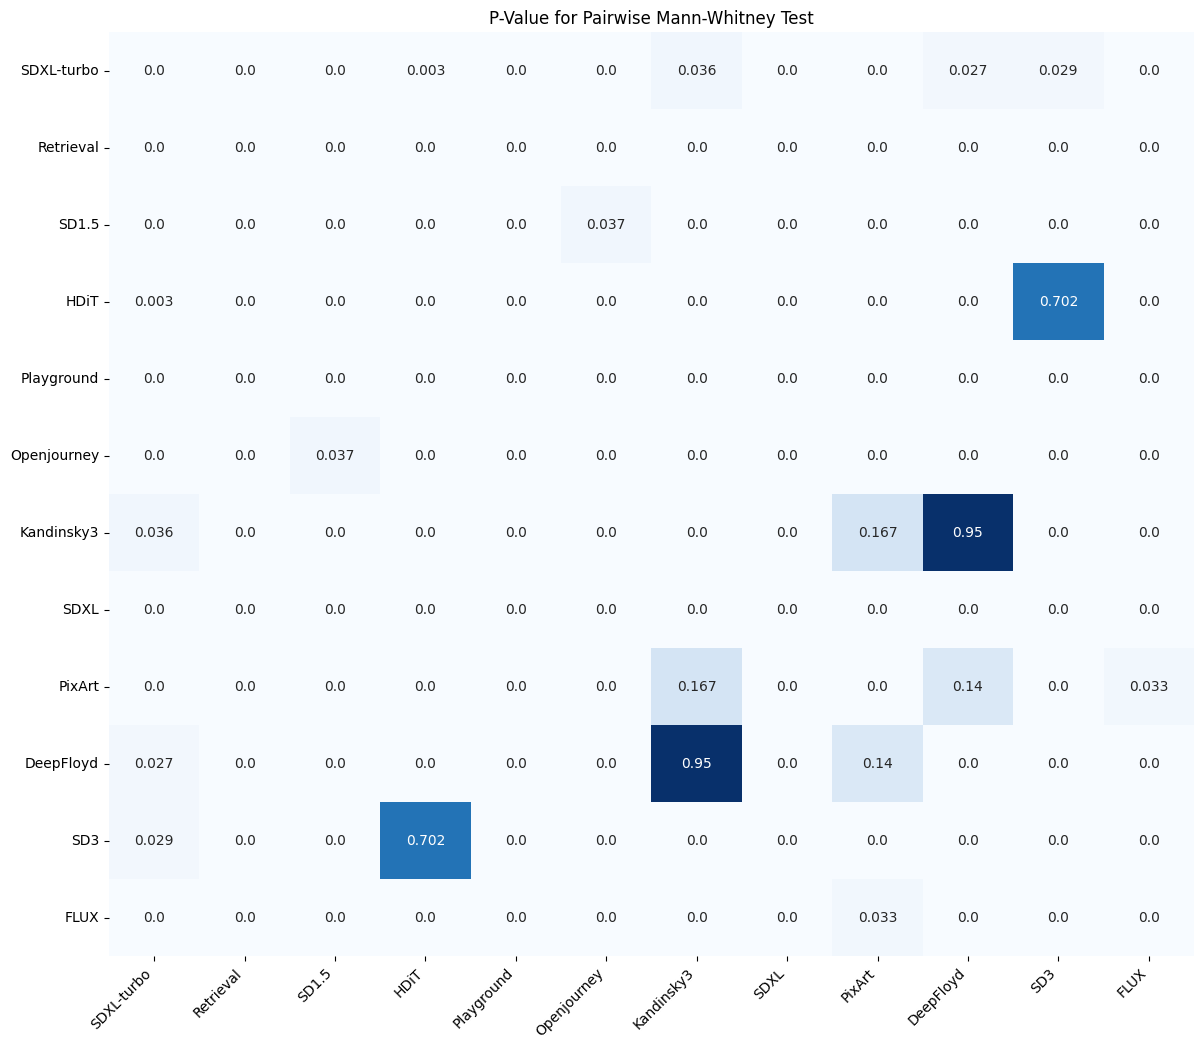

In [12]:

# plt.figure(figsize=(6, 4))
# sns.heatmap(conf_matrix[:2,:2], annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"fontsize":14}, xticklabels=['Model A', 'Model B'], yticklabels=['Model A', 'Model B'])
# #plt.title('Confusion Matrix of Human vs GPT')
# plt.xlabel('GPT Label', fontsize = 14)
# plt.ylabel('Human Label', fontsize = 14)
# plt.tight_layout()
# plt.savefig('conf_matrix.pdf', dpi=3000, bbox_inches='tight')
# plt.show()

# Plot as a heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(heatmap_matrix.values.astype(float), annot=True, fmt='', cmap="Blues", cbar=False,
            xticklabels=reward_columns.values(), yticklabels=reward_columns.values())
plt.title("P-Value for Pairwise Mann-Whitney Test")
plt.xticks(rotation=45, ha='right')  # Rotate x-ticks for better readability
plt.yticks(rotation=0)  # Keep y-ticks horizontal
plt.savefig('mann_whitney.pdf', dpi=3000, bbox_inches='tight')
plt.show()

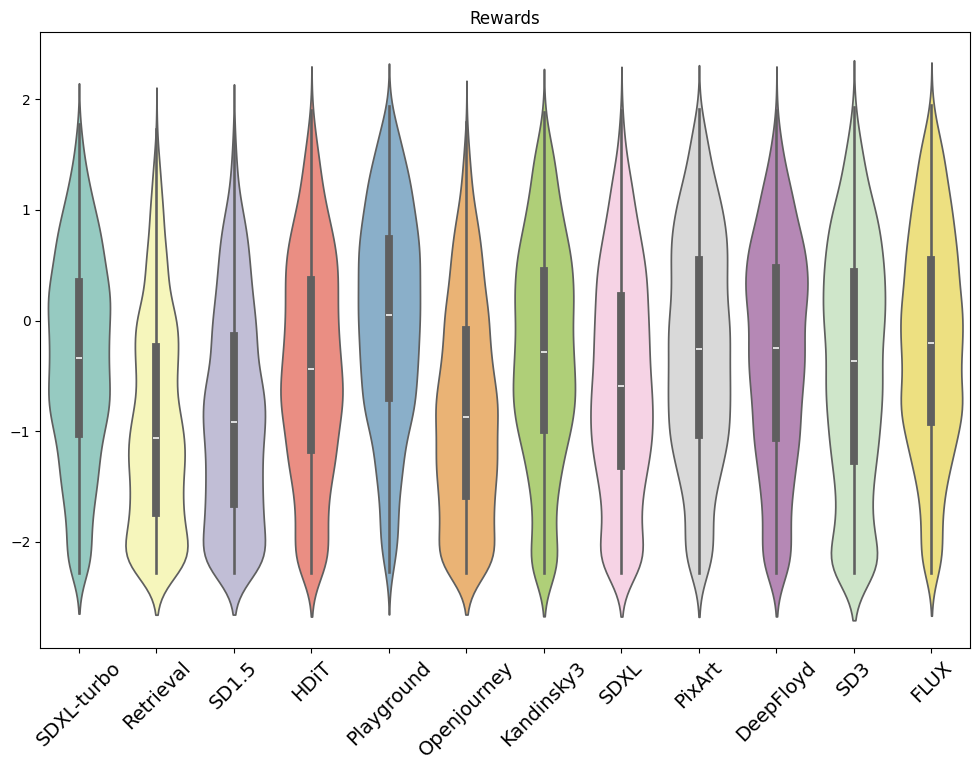

ANOVA results:
F-statistic: 272.444, p-value: 0.00000

Kruskal-Wallis results:
H-statistic: 2745.086, p-value: 0.00000


In [14]:
# 3. Plotting the boxplot
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_short[reward_columns.values()], palette='Set3')
plt.title('Rewards')
plt.xticks(fontsize=14, rotation=45)
plt.savefig('rewards_boxplot_main_with_flux.pdf', dpi=3000, bbox_inches='tight')
plt.show()

# 4. Print the results
print("ANOVA results:")
print(f"F-statistic: {anova_results.statistic:.3f}, p-value: {anova_results.pvalue:.5f}")

print("\nKruskal-Wallis results:")
print(f"H-statistic: {kruskal_results.statistic:.3f}, p-value: {kruskal_results.pvalue:.5f}")


In [15]:
df_short[reward_columns.values()].mean().sort_values(ascending=False).index

Index(['Playground', 'FLUX', 'PixArt', 'Kandinsky3', 'DeepFloyd', 'SDXL-turbo',
       'SD3', 'HDiT', 'SDXL', 'Openjourney', 'SD1.5', 'Retrieval'],
      dtype='object')

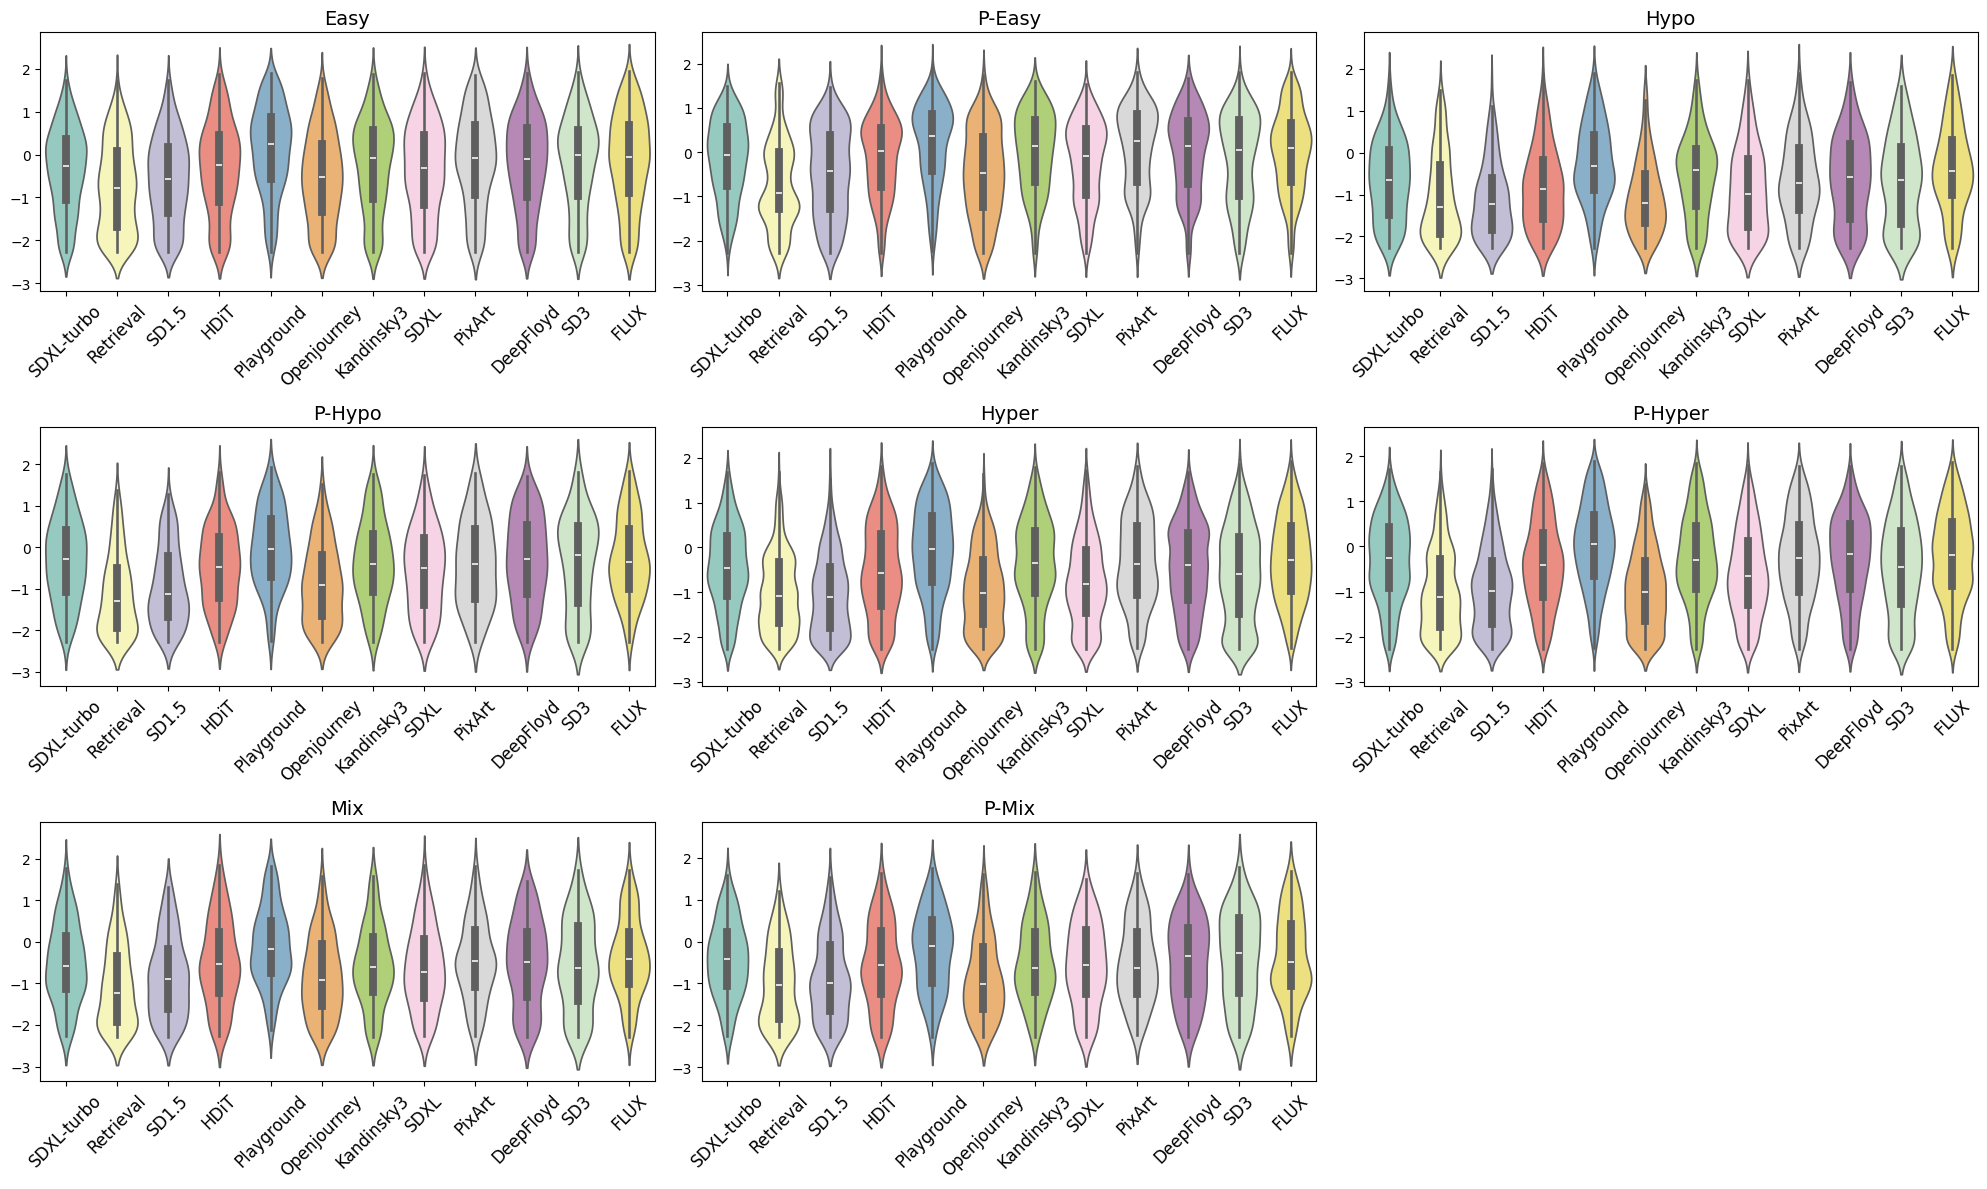

In [16]:
# Define the number of rows and columns for the grid of subplots
n_subplots = 8
rows, cols = 3, 3  # Creating a 3x3 grid but only plotting 8 subplots


subset_mapping = {
    'appendix': 'Easy',
    'appendix_llama': 'P-Easy',
    'leafs_and_no_leafs': 'Hypo',
    'leafs_and_no_leafs_llama': 'P-Hypo',
    'predict_hypernym': 'Hyper',
    'predict_hypernym_llama': 'P-Hyper',
    'simple_triplet_2parent': 'Mix',
    'simple_triplet_2parent_llama': 'P-Mix'
}

# Create a figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to easily iterate

# Subset-specific analysis
for i, (subset, data) in enumerate(grouped):
    data = data.rename(columns=reward_columns_mapping)

    # Plot each subset in its respective subplot
    sns.violinplot(data=data, palette='Set3', ax=axes[i])
    axes[i].set_title(f'{subset_mapping[subset]}', fontsize=14)
    axes[i].tick_params(axis='x', labelsize=12, rotation=45)

# Remove the last empty subplot (9th subplot)
for j in range(n_subplots, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig('subset_rewards_boxplot_with_flux.pdf', dpi=3000, bbox_inches='tight')
plt.show()

In [17]:
for i, (subset, data) in enumerate(grouped):
    data = data.rename(columns=reward_columns_mapping)
    print(subset, data.mean().index[data.mean().argmax()])

appendix Playground
appendix_llama Playground
leafs_and_no_leafs Playground
leafs_and_no_leafs_llama Playground
predict_hypernym Playground
predict_hypernym_llama Playground
simple_triplet_2parent Playground
simple_triplet_2parent_llama Playground


In [44]:
data.mean().index[data.mean().argmin()]

'Retrieval'

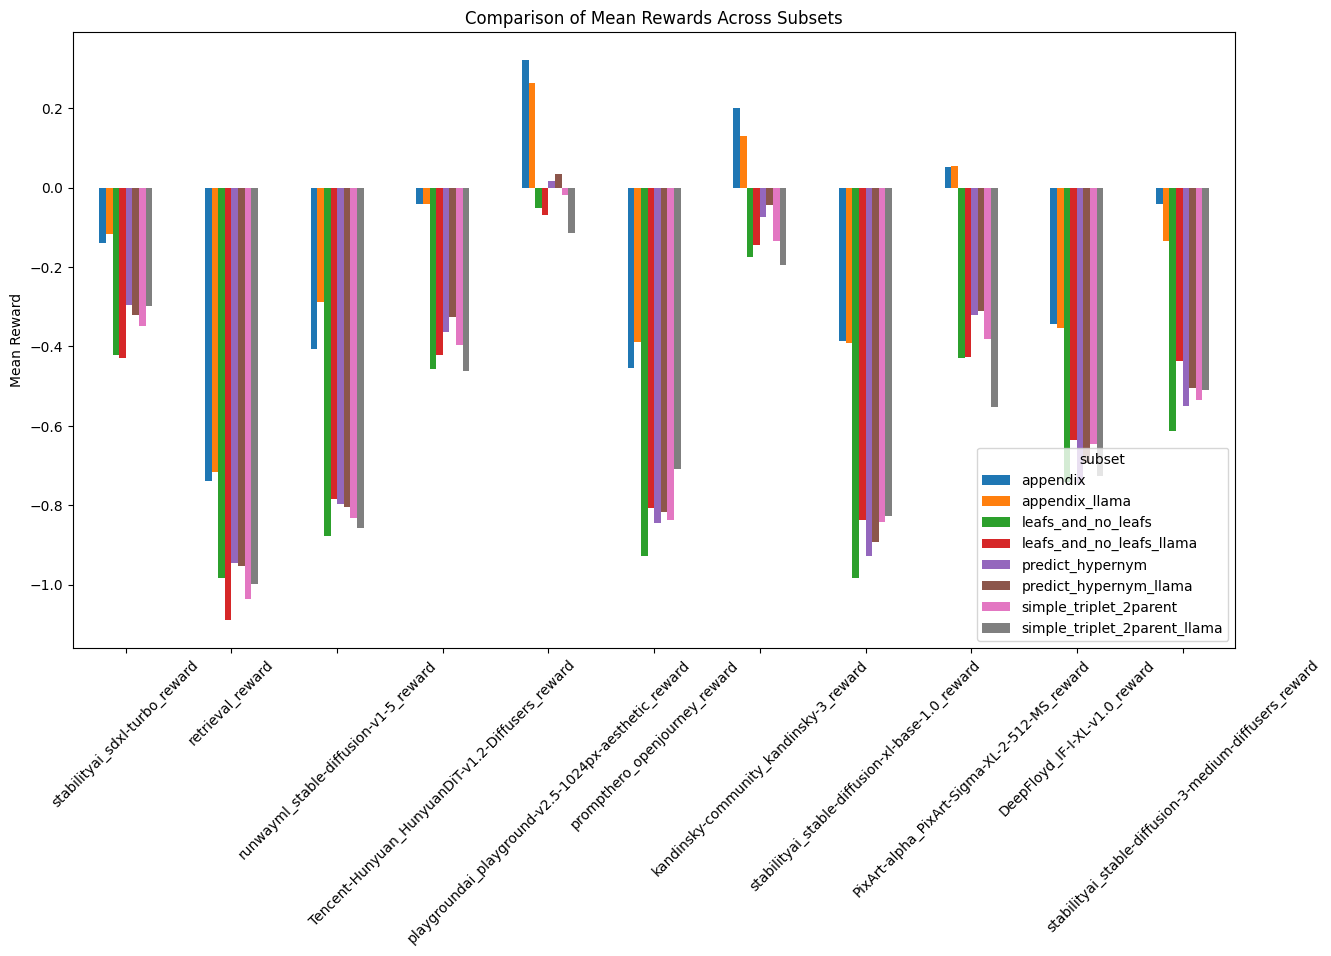

In [40]:

# Comparison across subsets
mean_rewards_by_subset = grouped.mean().transpose()
mean_rewards_by_subset.plot(kind='bar', figsize=(15, 8))
plt.title('Comparison of Mean Rewards Across Subsets')
plt.ylabel('Mean Reward')
plt.xticks(rotation=45)
plt.show()
